In [ ]:
import os
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import joblib

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

In [ ]:
COINS = ['BTC-USD', 'ETH-USD', 'DOGE-USD', 'SHIB-USD', 'FLOKI-USD']

START_DATE = "2022-01-01"
END_DATE = "2026-01-01"
INTERVAL = "1d"

LOOKBACK = 60       # INPUT 60 hari ke belakang
FORECAST = 7        # 7 hari prediksi
SPLIT_RATIO = 0.8   # 80% DATA UNTUK TRAINING

import tensorflow as tf
print(f"Versi Tensorflow: {tf.__version__}")
print("GPU status: " "Aktif" if tf.config.list_physical_devices('GPU') else "Tidak Aktif")

Versi Tensorflow: 2.19.0
GPU status: Aktif


In [ ]:
def get_data_with_indikacators(ticker, start, end, interval):
  # download data
  df = yf.download(ticker, start=start, end=end, interval=interval, progress=False)

  # Fix untuk yfinance versi baru (Menangani MultiIndex Column)
  if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

  # features engineering
  df['Log_Ret'] = np.log(df['Close'] / df['Close'].shift(1))

  # RSI (momentum)
  delta = df['Close'].diff()
  gain = delta.where(delta > 0, 0).rolling(window=14).mean()
  loss = -delta.where(delta < 0, 0).rolling(window=14).mean()
  rs = gain / loss
  df['RSI'] = 100 - (100 / (1 + rs))

  # macd (trend)
  ema12 = df['Close'].ewm(span=12, adjust=False).mean()
  ema26 = df['Close'].ewm(span=26, adjust=False).mean()
  df['MACD'] = ema12 - ema26
  df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

  # atr (volatilitas)
  high_low = df['High'] - df['Low']
  high_close = np.abs(df['High'] - df['Close'].shift(1))
  low_close = np.abs(df['Low'] - df['Close'].shift(1))

  ranges = pd.concat([high_low, high_close, low_close], axis=1)
  true_range = np.max(ranges, axis=1)

  df['ATR'] = true_range.rolling(window=14).mean()

  df.dropna(inplace=True)

  print(f"{ticker} siap! Data bersih: {len(df)} baris.")
  return df

test_df = get_data_with_indikacators("BTC-USD", START_DATE, END_DATE, INTERVAL)
print("\n Cek Kolom Data:")
print(test_df.columns)


BTC-USD siap! Data bersih: 1448 baris.

 Cek Kolom Data:
Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Log_Ret', 'RSI', 'MACD',
       'MACD_Signal', 'ATR'],
      dtype='object', name='Price')


/tmp/ipython-input-2592057878.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end, interval=interval, progress=False)


In [ ]:
from sklearn.preprocessing import MinMaxScaler

def create_dataset(df, lookback, forecast_days, split_ratio=0.8):
    # 1. PILIH FITUR
    features = ['Log_Ret', 'RSI', 'MACD', 'MACD_Signal', 'ATR', 'Volume']
    data = df[features].values

    # 2. SPLITTING
    train_size = int(len(data) * split_ratio)
    train_data = data[:train_size]
    test_data = data[train_size:]

    # 3. SCALING
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaler.fit(train_data) # Fit hanya training

    scaled_train = scaler.transform(train_data)
    scaled_test = scaler.transform(test_data)

    # 4. FUNGSI PEMBANTU SLIDING WINDOW
    def create_xy(dataset, lookback, forecast):
        X, y = [], []
        for i in range(lookback, len(dataset) - forecast + 1):
            X.append(dataset[i-lookback : i, :])
            y.append(dataset[i : i+forecast, 0])

        return np.array(X), np.array(y)

    # Bikin dataset training
    X_train, y_train = create_xy(scaled_train, lookback, forecast_days)

    # Khusus Testing: sisa data training
    last_60_days_train = scaled_train[-lookback:]
    final_test_input = np.concatenate((last_60_days_train, scaled_test), axis=0)

    X_test, y_test = create_xy(final_test_input, lookback, forecast_days)

    return X_train, y_train, X_test, y_test, scaler

In [ ]:
# testing
X_train, y_train, X_test, y_test, sclaer_btc = create_dataset(test_df, LOOKBACK, FORECAST, SPLIT_RATIO)

print("HASIL DATASET (Dimensi Matrix):")
print(f"X_train shape: {X_train.shape}  (Sampel, 60 Hari, 6 Fitur)")
print(f"y_train shape: {y_train.shape}   (Sampel, 7 Hari)")
print(f"X_test shape : {X_test.shape}")
print(f"y_test shape : {y_test.shape}")

HASIL DATASET (Dimensi Matrix):
X_train shape: (1092, 60, 6)  (Sampel, 60 Hari, 6 Fitur)
y_train shape: (1092, 7)   (Sampel, 7 Hari)
X_test shape : (284, 60, 6)
y_test shape : (284, 7)


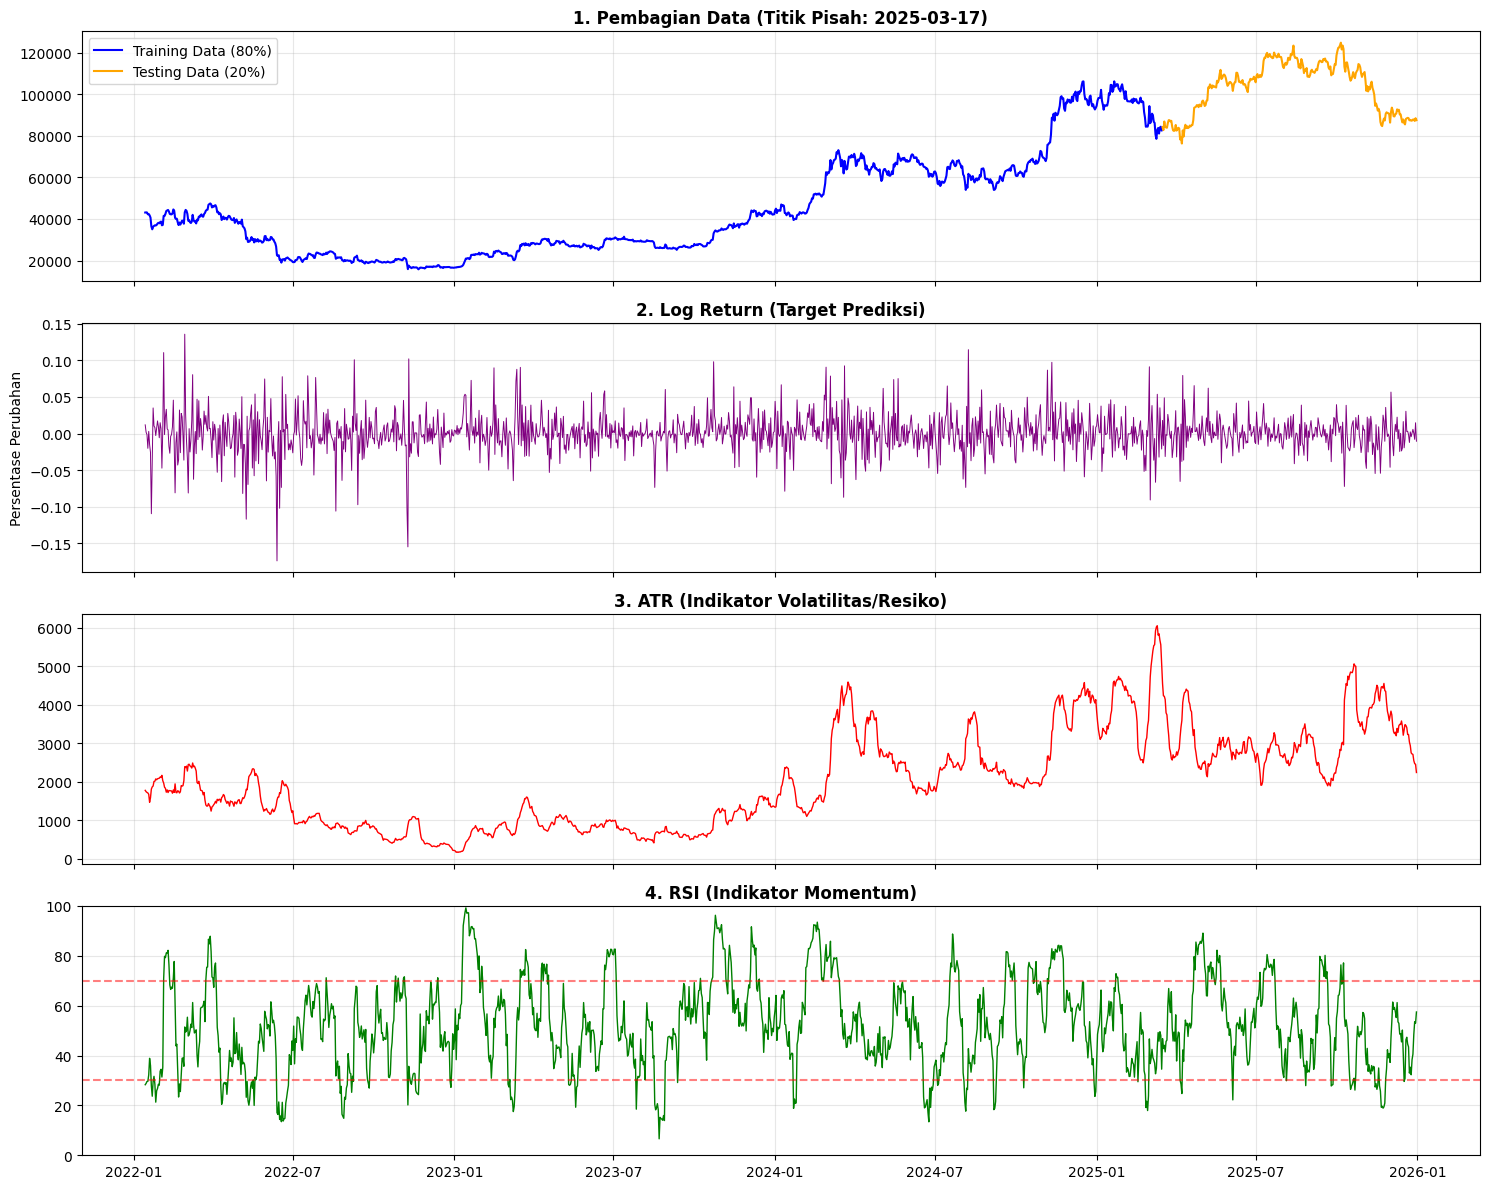

In [ ]:
def visualize_data_split(df, split_ratio):
    # Hitung titik potong
    split_idx = int(len(df) * split_ratio)
    date_split = df.index[split_idx]

    # Setup Canvas (4 Baris Grafik)
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(15, 12), sharex=True)

    # 1. HARGA ASLI (Close Price) - Memastikan Split Benar
    ax1.plot(df.index[:split_idx], df['Close'][:split_idx], label='Training Data (80%)', color='blue')
    ax1.plot(df.index[split_idx:], df['Close'][split_idx:], label='Testing Data (20%)', color='orange')
    ax1.set_title(f"1. Pembagian Data (Titik Pisah: {date_split.date()})", fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. LOG RETURN (Input Utama Model) - Mengecek Stasioneritas
    ax2.plot(df.index, df['Log_Ret'], color='purple', linewidth=0.7)
    ax2.set_title("2. Log Return (Target Prediksi)", fontweight='bold')
    ax2.set_ylabel("Persentase Perubahan")
    ax2.grid(True, alpha=0.3)

    # 3. VOLATILITAS (ATR) - Mengecek 'Badai'
    ax3.plot(df.index, df['ATR'], color='red', linewidth=1)
    ax3.set_title("3. ATR (Indikator Volatilitas/Resiko)", fontweight='bold')
    ax3.grid(True, alpha=0.3)

    # 4. MOMENTUM (RSI) - Mengecek Kesehatan Pasar
    ax4.plot(df.index, df['RSI'], color='green', linewidth=1)
    ax4.axhline(70, color='red', linestyle='--', alpha=0.5) # Batas Overbought
    ax4.axhline(30, color='red', linestyle='--', alpha=0.5) # Batas Oversold
    ax4.set_title("4. RSI (Indikator Momentum)", fontweight='bold')
    ax4.set_ylim(0, 100)
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# --- JALANKAN VISUALISASI ---
visualize_data_split(test_df, SPLIT_RATIO)

In [ ]:
# Cek 5 data paling ujung (buntut)
print("🔍 DATA TERAKHIR DALAM TABEL:")
print(test_df.tail())

print("\n🗓️ TANGGAL PALING AKHIR ADALAH:")
print(test_df.index[-1])

🔍 DATA TERAKHIR DALAM TABEL:
Price              Close          High           Low          Open  \
Date                                                                 
2025-12-27  87802.156250  87874.781250  87182.976562  87301.429688   
2025-12-28  87835.835938  87986.890625  87394.953125  87799.343750   
2025-12-29  87138.140625  90299.156250  86717.914062  87835.789062   
2025-12-30  88430.132812  89297.937500  86735.546875  87134.351562   
2025-12-31  87508.828125  89080.289062  87130.562500  88429.585938   

Price            Volume   Log_Ret        RSI         MACD  MACD_Signal  \
Date                                                                     
2025-12-27  13741199310  0.005719  40.539193 -1226.613954 -1437.916569   
2025-12-28  15156557929  0.000384  48.472022 -1141.899805 -1378.713216   
2025-12-29  48411625849 -0.007975  53.575122 -1118.171823 -1326.604938   
2025-12-30  35586356225  0.014718  52.956037  -983.773922 -1258.038735   
2025-12-31  33830210616 -0.010473  5

In [ ]:
from tensorflow.keras.layers import Input
def build_model(input_shape, ouput_units):
    model = Sequential()

    model.add(Input(shape=input_shape))

    model.add(LSTM(units=64, return_sequences=True))
    model.add(Dropout(0.2))

    model.add(LSTM(units=32, return_sequences=False))
    model.add(Dropout(0.2))

    model.add(Dense(units=ouput_units))


    learning_rate = Adam(learning_rate=0.001)
    model.compile(optimizer='adam', loss='mean_squared_error')

    return model

In [ ]:
# test model
sample_shape = (X_train.shape[1], X_train.shape[2])
model_test = build_model(sample_shape, 7)
model_test.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 60, 64)         │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,823 (120.40 KB)

 Trainable params: 30,823 (120.40 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
if not os.path.exists('models'):
    os.makedirs('models')

if not os.path.exists('scalers'):
    os.makedirs('scalers')

# dictionary untuk menyimpan history (grafik)
history_dict = {}

print(f"Memulai Training System Untuk {len(COINS)} KOIN")
print(f"Mode: Early Stopping &  Auto-Save Best Model Aktif")
print("="*50)

for ticker in COINS:
    print(f"\n [1/3] Memproses Data: {ticker}...")

    # A. Load Data
    df = get_data_with_indikacators(ticker, START_DATE, END_DATE, INTERVAL)

    # B. Create Dataset
    X_train, y_train, X_test, y_test, scaler = create_dataset(df, LOOKBACK, FORECAST, SPLIT_RATIO)

    # C. Simpan Scaler
    scaler_path = f"scalers/{ticker}_scaler.pkl"
    joblib.dump(scaler, scaler_path)

    print(f"[2/3] Membangun Arsitektur Model: {ticker}...")

    # D. Build Model
    input_shape = (X_train.shape[1], X_train.shape[2])
    model = build_model(input_shape, FORECAST)

    # E. Callbacks (pengaman)
    # 1. Early Stopping: Berhenti jika tidak ada kemajuan
    early_stop = EarlyStopping(
        monitor='val_loss',       # Yang dipantau: Error pada data ujian (Testing)
        patience=10,              # Sabar menunggu 10 epoch. Kalau gak turun2, stop.
        restore_best_weights=True # Kembalikan otak ke kondisi terpintar, bukan terakhir.
    )

    # 2. Model Checkpoint: Simpan file hanya saat mencetak rekor baru
    save_path = f"models/{ticker}_best_model.keras"
    checkpoint = ModelCheckpoint(
        filepath=save_path,
        monitor='val_loss',
        save_best_only=True,      # Hanya simpan jika ini model terbaik sejauh ini
        mode='min',               # cari loss yang paling MINIMAL (kecil)
        verbose=0
    )

    print(f"👉 [3/3] Mulai Training (Max 50 Epochs)...")

    # F. EKSEKUSI TRAINING
    history = model.fit(
        X_train, y_train,
        epochs=50,                # Batas maksimal (bisa berhenti lebih cepat karena EarlyStopping)
        batch_size=32,            # Update bobot setiap 32 soal
        validation_data=(X_test, y_test), # Data ujian untuk mengecek kepintaran
        callbacks=[early_stop, checkpoint], # Pasang pengaman
        verbose=1                 # Tampilkan progress bar
    )

    # G. SIMPAN RIWAYAT BELAJAR
    history_dict[ticker] = history

    print(f"✅ Selesai! Model terbaik disimpan di: {save_path}")
    print(f"✅ Scaler disimpan di: {scaler_path}")
    print("-" * 80)

print("\n🎉 MISI SELESAI! SEMUA MODEL SUDAH DILATIH DAN DISIMPAN.")

Memulai Training System Untuk 5 KOIN
Mode: Early Stopping &  Auto-Save Best Model Aktif

 [1/3] Memproses Data: BTC-USD...
BTC-USD siap! Data bersih: 1448 baris.
[2/3] Membangun Arsitektur Model: BTC-USD...


/tmp/ipython-input-2592057878.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end, interval=interval, progress=False)


👉 [3/3] Mulai Training (Max 50 Epochs)...
Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - loss: 0.1614 - val_loss: 0.0076
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0291 - val_loss: 0.0052
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0238 - val_loss: 0.0049
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0211 - val_loss: 0.0046
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0193 - val_loss: 0.0044
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0190 - val_loss: 0.0052
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0168 - val_loss: 0.0044
Epoch 8/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0168 - val_loss: 0.0049
Epoch 9/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0157 - val_loss: 0.0047
Epoch 10/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0153 - val_loss: 0.0044
Epoch 11/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0147 - val_loss: 0.0044
Epoch 12/50
35/35 ━━━

/tmp/ipython-input-2592057878.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end, interval=interval, progress=False)


Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.1351 - val_loss: 0.0151
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0272 - val_loss: 0.0123
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0224 - val_loss: 0.0131
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0210 - val_loss: 0.0113
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0191 - val_loss: 0.0113
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0174 - val_loss: 0.0119
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0173 - val_loss: 0.0113
Epoch 8/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0171 - val_loss: 0.0110
Epoch 9/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0160 - val_loss: 0.0127
Epoch 10/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0154 - val_loss: 0.0109
Epoch 11/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0154 - val_loss: 0.0114
Epoch 12/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0

...

Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0995 - val_loss: 0.0104
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0171 - val_loss: 0.0067
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0137 - val_loss: 0.0063
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0126 - val_loss: 0.0062
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0116 - val_loss: 0.0062
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0104 - val_loss: 0.0061
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0106 - val_loss: 0.0060
Epoch 8/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0108 - val_loss: 0.0060
Epoch 9/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0102 - val_loss: 0.0060
Epoch 10/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0095 - val_loss: 0.0061
Epoch 11/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0094 - val_loss: 0.0061
Epoch 12/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0

/tmp/ipython-input-2592057878.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end, interval=interval, progress=False)


Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0727 - val_loss: 0.0059
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0172 - val_loss: 0.0054
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0137 - val_loss: 0.0050
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0125 - val_loss: 0.0048
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0117 - val_loss: 0.0047
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0112 - val_loss: 0.0049
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0104 - val_loss: 0.0047
Epoch 8/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0102 - val_loss: 0.0046
Epoch 9/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0094 - val_loss: 0.0046
Epoch 10/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0094 - val_loss: 0.0047
Epoch 11/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0092 - val_loss: 0.0046
Epoch 12/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0

/tmp/ipython-input-2592057878.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end, interval=interval, progress=False)


34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0864 - val_loss: 0.0078
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0203 - val_loss: 0.0066
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0169 - val_loss: 0.0059
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0157 - val_loss: 0.0059
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0139 - val_loss: 0.0057
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0139 - val_loss: 0.0059
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0129 - val_loss: 0.0055
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0125 - val_loss: 0.0056
Epoch 9/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0130 - val_loss: 0.0056
Epoch 10/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0122 - val_loss: 0.0056
Epoch 11/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0121 - val_loss: 0.0056
Epoch 12/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0119 - val_l

✅ Menampilkan Grafik Training untuk 5 Koin...



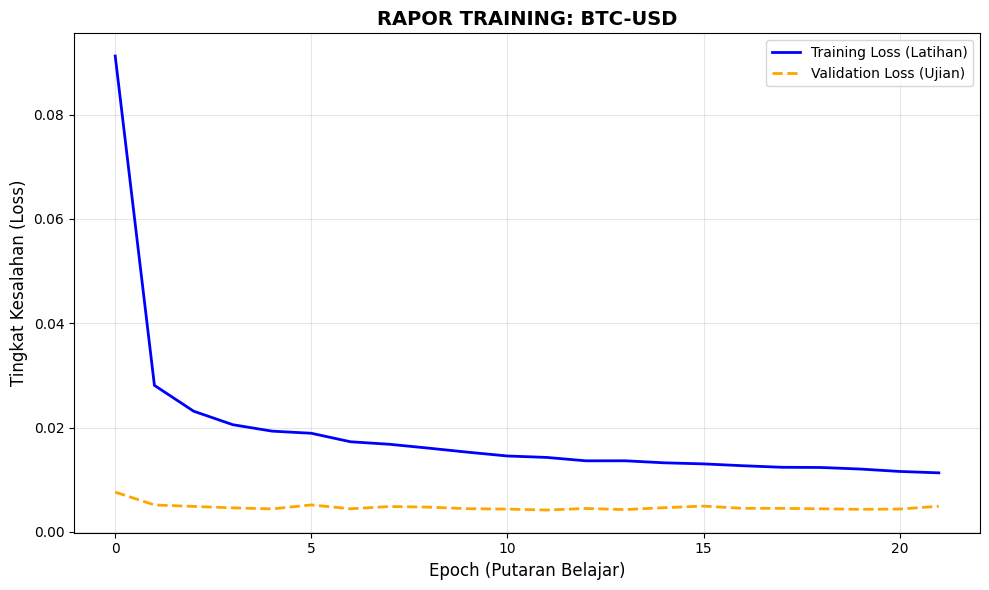

Analisa Singkat BTC-USD:
👉 Akhir Training Loss: 0.01132
👉 Akhir Validation Loss: 0.00492
------------------------------------------------------------


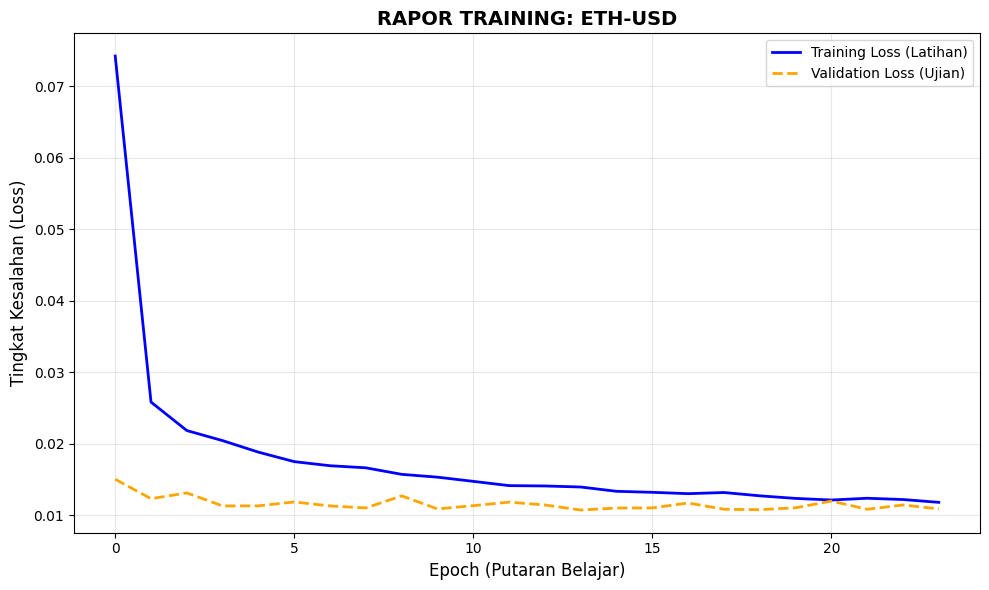

Analisa Singkat ETH-USD:
👉 Akhir Training Loss: 0.01182
👉 Akhir Validation Loss: 0.01090
------------------------------------------------------------


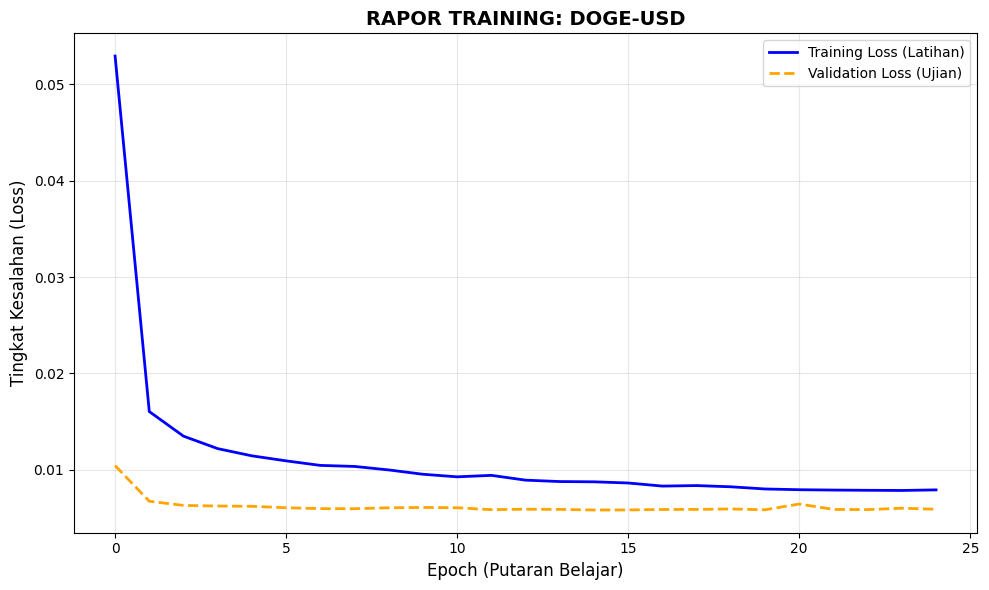

Analisa Singkat DOGE-USD:
👉 Akhir Training Loss: 0.00791
👉 Akhir Validation Loss: 0.00589
------------------------------------------------------------


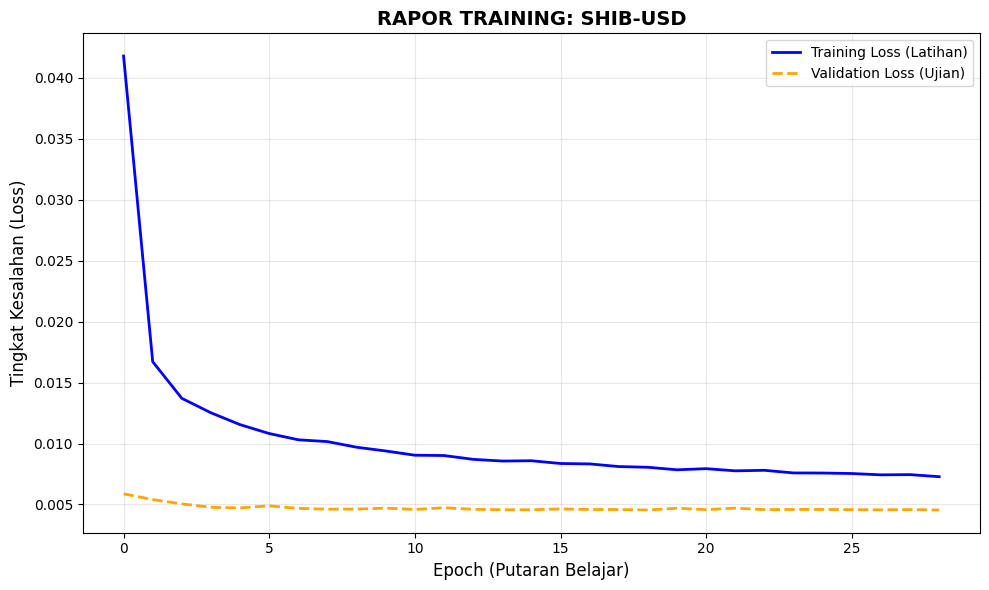

Analisa Singkat SHIB-USD:
👉 Akhir Training Loss: 0.00728
👉 Akhir Validation Loss: 0.00454
------------------------------------------------------------


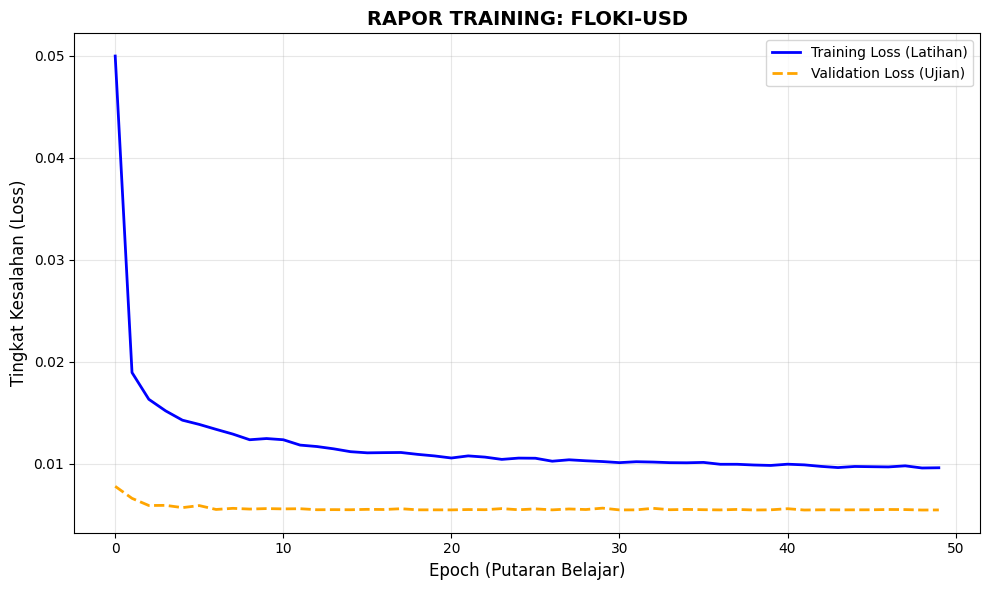

Analisa Singkat FLOKI-USD:
👉 Akhir Training Loss: 0.00961
👉 Akhir Validation Loss: 0.00548
------------------------------------------------------------


In [ ]:
import matplotlib.pyplot as plt

# Cek apakah data history masih tersimpan di memori
if 'history_dict' not in globals() or not history_dict:
    print("⚠️ MAAF, Data History Kosong.")
    print("Kemungkinan sesi Google Colab Anda sempat terputus/restart.")
    print("Anda perlu menjalankan ulang Langkah 5 (Training) untuk melihat grafik ini.")
else:
    print(f"✅ Menampilkan Grafik Training untuk {len(history_dict)} Koin...\n")

    # Loop untuk menggambar grafik setiap koin
    for ticker, history in history_dict.items():
        if history is None:
            continue

        plt.figure(figsize=(10, 6))

        # 1. Garis Biru: Error saat Latihan (Training)
        plt.plot(history.history['loss'], label='Training Loss (Latihan)', color='blue', linewidth=2)

        # 2. Garis Oranye: Error saat Validasi (Validation/Ujian)
        if 'val_loss' in history.history:
            plt.plot(history.history['val_loss'], label='Validation Loss (Ujian)', color='orange', linewidth=2, linestyle='--')

        plt.title(f'RAPOR TRAINING: {ticker}', fontsize=14, fontweight='bold')
        plt.ylabel('Tingkat Kesalahan (Loss)', fontsize=12)
        plt.xlabel('Epoch (Putaran Belajar)', fontsize=12)
        plt.legend(loc='upper right')
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show() # Tampilkan gambar

        print(f"Analisa Singkat {ticker}:")
        final_train_loss = history.history['loss'][-1]
        final_val_loss = history.history['val_loss'][-1]
        print(f"👉 Akhir Training Loss: {final_train_loss:.5f}")
        print(f"👉 Akhir Validation Loss: {final_val_loss:.5f}")
        print("-" * 60)

In [ ]:
import shutil
from google.colab import files

print("📦 Sedang memproses pengemasan file...")

# 1. Zip Folder Models
shutil.make_archive('my_crypto_models', 'zip', 'models')

# 2. Zip Folder Scalers
shutil.make_archive('my_crypto_scalers', 'zip', 'scalers')

print("✅ File ZIP berhasil dibuat!")
print("⬇️ Mengunduh ke komputer lokal Anda...")

# 3. Trigger Download Browser
files.download('my_crypto_models.zip')
files.download('my_crypto_scalers.zip')

print("Catatan: Jika download tidak muncul, cek 'Pop-up Blocker' di browser Anda.")

📦 Sedang memproses pengemasan file...
✅ File ZIP berhasil dibuat!
⬇️ Mengunduh ke komputer lokal Anda...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Catatan: Jika download tidak muncul, cek 'Pop-up Blocker' di browser Anda.
